In [13]:
from libraries import *
from parameters import *
from util import *

from __future__ import annotations

from pathlib import Path
from typing import Any
import numpy as np
import pandas as pd



In [14]:
a=pd.read_csv("./../../TextFiles/gene_by_drug_nsig_fdr_lt_0p1.csv", index_col=0)
b=pd.read_csv("./../../TextFiles/perturbation_by_drug_nsig_genes_fdr_lt_0p1.csv",index_col=0)
a["TOTAL"] = a.drop(columns=["MEDIAN"]).sum(axis=1)


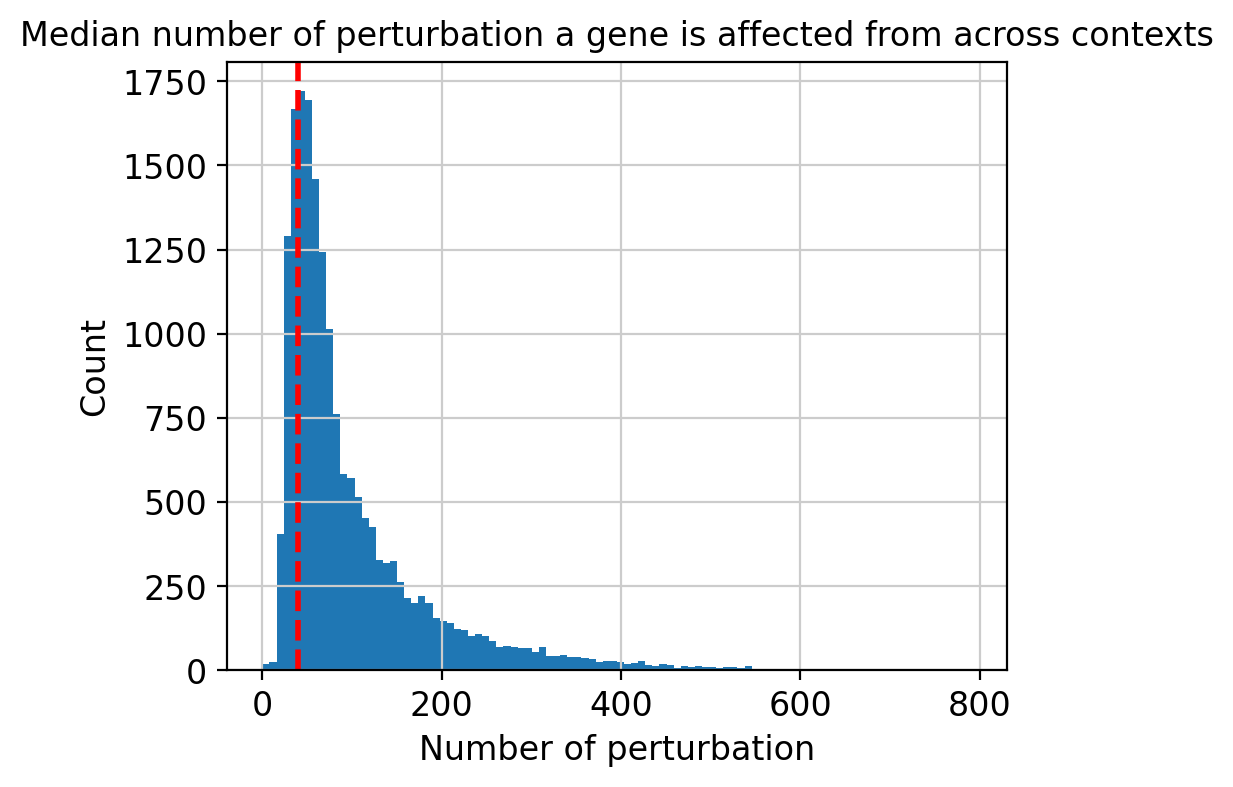

7512

In [15]:
plt.figure(figsize=(5, 4))
plt.hist(a["MEDIAN"].dropna(), bins=100)
plt.axvline(
    x=40,
    color="red",
    linestyle="--",
    linewidth=2,
    label="x = 50"
)
plt.xlabel("Number of perturbation")
plt.ylabel("Count")
plt.title("Median number of perturbation a gene is affected from across contexts")
plt.show()
selGenes=list(a.loc[a.MEDIAN > 80,:].index)
len(selGenes)

In [16]:
b

,AR-A014418,AZD4573,CHIR-98014,DMSO_round2,Lexibulin,PP121,Romidepsin,Stattic,Bisindolylmaleimide-I,DG-172,DMSO_round2_batch2,JTE-607,LDN-193189,LY2090314,NSC95397,VX-11e,TOTAL,MEDIAN
STRAP,8953,7922,7749,7576,8723,7078,7596,8747,8285,8266,7295,6496,8209,7362,8078,6564,124899,7835.5
EFEMP1,8587,7009,5147,6804,7984,6838,6818,8822,7852,8958,6527,8014,8762,5197,8622,7264,119205,7558.0
CSDE1,7800,7587,7701,6766,8158,6872,6591,8000,7860,8088,6889,6402,7772,7375,7918,5888,117667,7644.0
SMARCA5,7283,7324,5674,6350,7831,7778,7125,8584,7405,8332,6072,7897,8319,4120,8238,7606,115938,7505.5
TADA1,8658,6363,4151,5816,7187,6350,5772,7906,7568,8546,5593,7328,8461,4435,7550,6094,107778,6775.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VPS28,170,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,170,0.0
POLR2I,0,0,0,0,0,0,0,0,0,169,0,0,0,0,0,0,169,0.0
ERCC2,55,0,0,0,0,63,0,0,0,39,0,0,0,0,0,0,157,0.0
ZC3H8,0,0,0,0,0,0,147,0,0,0,0,0,0,0,0,0,147,0.0


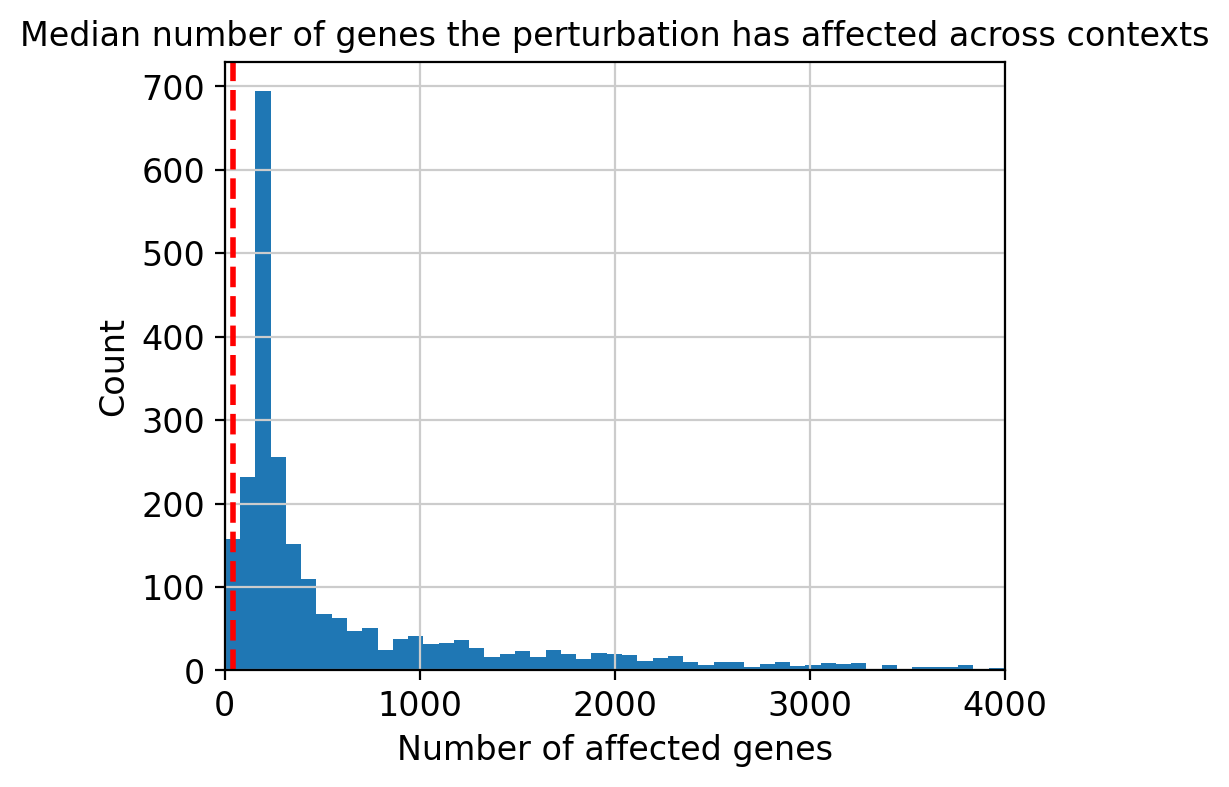

2351

In [24]:
plt.figure(figsize=(5, 4))
plt.hist(b["MEDIAN"].dropna(), bins=100)
plt.axvline(
    x=40,
    color="red",
    linestyle="--",
    linewidth=2,
    label="x = 50"
)
plt.xlim(0,4000)
plt.xlabel("Number of affected genes")
plt.ylabel("Count")
plt.title("Median number of genes the perturbation has affected across contexts")
plt.show()
selPerts=list(b.loc[b.MEDIAN > 50,:].index)
len(selPerts)

In [18]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd


def _load_matrix_csv(path: Path) -> pd.DataFrame:
    """Load a matrix CSV with rownames in col 0."""
    return pd.read_csv(path, index_col=0)


def _overlap_from_two_mats(
    X_df: pd.DataFrame,
    Y_df: pd.DataFrame,
    *,
    sel_perts: list[str] | pd.Index | None = None,
    sel_genes: list[str] | pd.Index | None = None,
    k: int = 100,
    axis: str = "rows",   # "rows" or "cols"
    center: str = "cols", # "cols" or "rows" or "none"
    min_common_rows: int = 50,
    min_common_cols: int = 50,
) -> float:
    """
    Compute subspace overlap between two matrices after:
      (1) filtering to sel_perts/sel_genes (if provided),
      (2) aligning by intersection of row/col labels between the pair.

    overlap = mean(sigmas^2) where sigmas are singular values of Q1^T Q2.
    ""5
    # ---- optional pre-filtering to user-selected sets ----
    if sel_perts is not None:
        sel_perts = pd.Index(sel_perts)
        X_df = X_df.loc[X_df.index.intersection(sel_perts)]
        Y_df = Y_df.loc[Y_df.index.intersection(sel_perts)]

    if sel_genes is not None:
        sel_genes = pd.Index(sel_genes)
        X_df = X_df.loc[:, X_df.columns.intersection(sel_genes)]
        Y_df = Y_df.loc[:, Y_df.columns.intersection(sel_genes)]

    # ---- align pair on intersection ----
    common_rows = X_df.index.intersection(Y_df.index)
    common_cols = X_df.columns.intersection(Y_df.columns)

    if len(common_rows) < min_common_rows:
        raise ValueError(f"Too few common rows after filtering: {len(common_rows)} (<{min_common_rows}).")
    if len(common_cols) < min_common_cols:
        raise ValueError(f"Too few common cols after filtering: {len(common_cols)} (<{min_common_cols}).")

    X = X_df.loc[common_rows, common_cols].to_numpy(dtype=np.float64, copy=False)
    Y = Y_df.loc[common_rows, common_cols].to_numpy(dtype=np.float64, copy=False)

    # ---- centering ----
    if center == "cols":
        X = X - X.mean(axis=0, keepdims=True)
        Y = Y - Y.mean(axis=0, keepdims=True)
    elif center == "rows":
        X = X - X.mean(axis=1, keepdims=True)
        Y = Y - Y.mean(axis=1, keepdims=True)
    elif center == "none":
        pass
    else:
        raise ValueError("center must be 'cols', 'rows', or 'none'")

    # ---- SVDs ----
    U1, _, Vt1 = np.linalg.svd(X, full_matrices=False)
    U2, _, Vt2 = np.linalg.svd(Y, full_matrices=False)

    if axis == "rows":
        k_eff = min(k, U1.shape[1], U2.shape[1])
        Q1 = U1[:, :k_eff]
        Q2 = U2[:, :k_eff]
    elif axis == "cols":
        k_eff = min(k, Vt1.shape[0], Vt2.shape[0])
        Q1 = Vt1.T[:, :k_eff]
        Q2 = Vt2.T[:, :k_eff]
    else:
        raise ValueError("axis must be 'rows' or 'cols'")

    # ---- principal-angle singular values ----
    M = Q1.T @ Q2
    sigmas = np.linalg.svd(M, compute_uv=False)
    sigmas = np.clip(sigmas[:k_eff], 0.0, 1.0)

    return float(np.mean(sigmas ** 2))


def compute_pairwise_overlaps(
    *,
    in_dir: str | Path = "PosteriorMeanMatrices",
    pattern: str = "PosteriorMean_matrix_*.csv",
    selPerts: list[str] | pd.Index | None = None,
    selGenes: list[str] | pd.Index | None = None,
    k: int = 100,
    center: str = "cols",
    out_rows_csv: str | Path = "overlap_rows.csv",
    out_cols_csv: str | Path = "overlap_cols.csv",
    min_common_rows: int = 50,
    min_common_cols: int = 50,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    For all matrices in in_dir/pattern, compute pairwise overlap matrices:
      - rows: overlap of left-singular-vector subspaces (perturbation geometry)
      - cols: overlap of right-singular-vector subspaces (gene geometry)

    Before pairwise alignment, each matrix is filtered to:
      rows in selPerts (if provided) and columns in selGenes (if provided).

    Saves two CSVs and returns (rows_overlap_df, cols_overlap_df).
    """
    in_dir = Path(in_dir)
    files = sorted(in_dir.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No files matched {in_dir}/{pattern}")

    def _cond_name(p: Path) -> str:
        return p.stem.replace("PosteriorMean_matrix_", "")

    names = [_cond_name(f) for f in files]

    # Load all once
    mats: dict[str, pd.DataFrame] = {nm: _load_matrix_csv(f) for nm, f in zip(names, files)}

    # Optional global filtering (per matrix, using intersection)
    if selPerts is not None:
        selPerts_idx = pd.Index(selPerts)
        for nm in names:
            mats[nm] = mats[nm].loc[mats[nm].index.intersection(selPerts_idx)]
    if selGenes is not None:
        selGenes_idx = pd.Index(selGenes)
        for nm in names:
            mats[nm] = mats[nm].loc[:, mats[nm].columns.intersection(selGenes_idx)]

    n = len(names)
    rows_ov = pd.DataFrame(np.eye(n, dtype=float), index=names, columns=names)
    cols_ov = pd.DataFrame(np.eye(n, dtype=float), index=names, columns=names)

    for i in range(n):
        for j in range(i + 1, n):
            a = names[i]
            b = names[j]

            ov_r = _overlap_from_two_mats(
                mats[a], mats[b],
                sel_perts=None, sel_genes=None,  # already filtered globally above
                k=k, axis="rows", center=center,
                min_common_rows=min_common_rows,
                min_common_cols=min_common_cols,
            )
            ov_c = _overlap_from_two_mats(
                mats[a], mats[b],
                sel_perts=None, sel_genes=None,
                k=k, axis="cols", center=center,
                min_common_rows=min_common_rows,
                min_common_cols=min_common_cols,
            )

            rows_ov.loc[a, b] = rows_ov.loc[b, a] = ov_r
            cols_ov.loc[a, b] = cols_ov.loc[b, a] = ov_c

            print(f"[{a} vs {b}] rows_overlap={ov_r:.4f} cols_overlap={ov_c:.4f}")

    Path(out_rows_csv).parent.mkdir(parents=True, exist_ok=True)
    Path(out_cols_csv).parent.mkdir(parents=True, exist_ok=True)
    rows_ov.to_csv(out_rows_csv)
    cols_ov.to_csv(out_cols_csv)

    print(f"[done] wrote: {out_rows_csv}")
    print(f"[done] wrote: {out_cols_csv}")

    return rows_ov, cols_ov





In [20]:
# Example:
rows_ov, cols_ov = compute_pairwise_overlaps(
    in_dir="./../../PosteriorMeanMatrices",
    pattern="PosteriorMean_matrix_*.csv",
    selPerts=selPerts,
    selGenes=selGenes,
    k=100,
    out_rows_csv="Ooverlap_rows.csv",
    out_cols_csv="overlap_cols.csv",
)

KeyboardInterrupt: 

In [ ]:
Cond_X=pd.read_csv("PosteriorMeanMatrices/PosteriorMean_matrix_DMSO_round2.csv", index_col=0)
Cond_Y=pd.read_csv("PosteriorMeanMatrices/PosteriorMean_matrix_DMSO_round2_batch2.csv", index_col=0)

selPerts_ok = Cond_X.index.intersection(selPerts)
selPerts_ok = Cond_Y.index.intersection(selPerts_ok)

selGenes_ok = Cond_X.columns.intersection(selGenes)
selGenes_ok = Cond_X.columns.intersection(selGenes_ok)


Cond_X = Cond_X.loc[selPerts_ok, selGenes_ok]
Cond_Y = Cond_Y.loc[selPerts_ok, selGenes_ok]

Cond_X = np.asarray(Cond_X)
Cond_Y = np.asarray(Cond_Y)

Cond_X = Cond_X - Cond_X.mean(axis=0, keepdims=True)
Cond_Y = Cond_Y - Cond_Y.mean(axis=0, keepdims=True)

U1, S1, Vt1 = np.linalg.svd(Cond_X, full_matrices=False)
U2, S2, Vt2 = np.linalg.svd(Cond_Y, full_matrices=False)

k=100
axis="rows"
if axis == "rows":
    Q1 = U1[:, :k]
    Q2 = U2[:, :k]
elif axis == "cols":
    Q1 = Vt1.T[:, :k]
    Q2 = Vt2.T[:, :k]
else:
    raise ValueError("axis must be 'rows' or 'cols'")

M = Q1.T @ Q2
_, sigmas, _ = np.linalg.svd(M, full_matrices=False)
sigmas = np.clip(sigmas[:k], 0.0, 1.0)
overlap = float(np.mean(sigmas**2))

overlap


In [ ]:
from __future__ import annotations

from pathlib import Path
from typing import Any
import numpy as np
import pandas as pd


def compute_context_jaccards_to_files(
    folder: str | Path,
    prefixes: list[str],
    selGenes: list[str] | None = None,
    selPerts: list[str] | None = None,
    *,
    baseline_prefix: str = "DMSO_round2",
    fdr_suffix: str = "_FDRs.csv",
    fdr_threshold: float = 0.05,
    index_col: int | None = 0,
    outdir: str | Path | None = None,
    out_prefix: str = "jaccard_vs_baseline",
    on_missing: str = "drop",  # {"drop","raise"}
    verbose: bool = True,
) -> dict[str, Any]:
    """
    Computes Jaccard similarities vs a baseline context (default: DMSO_round2)
    and writes TWO CSV outputs:

      1) <out_prefix>_perturbations.csv
         - rows: perturbations
         - cols: [baseline_sig_n_genes] + one column per context (Jaccard vs baseline)

      2) <out_prefix>_genes.csv
         - rows: genes
         - cols: [baseline_sig_n_perts] + one column per context (Jaccard vs baseline)

    Definitions:
      - "Affected" means FDR <= fdr_threshold within the selected gene/pert subsets.
      - Perturbation Jaccard compares affected genes (row-wise).
      - Gene Jaccard compares affected perturbations (col-wise).

    Missing handling:
      - on_missing="drop" (default): intersect selections with what's in baseline and proceed.
      - on_missing="raise": raise if selGenes/selPerts not found in baseline, or if any context
        is missing aligned rows/cols.
    """
    if on_missing not in {"drop", "raise"}:
        raise ValueError(f"on_missing must be 'drop' or 'raise', got: {on_missing}")

    folder = Path(folder)
    outdir = Path(outdir) if outdir is not None else folder
    outdir.mkdir(parents=True, exist_ok=True)

    def _read(prefix: str) -> pd.DataFrame:
        fp = folder / f"{prefix}{fdr_suffix}"
        if not fp.exists():
            raise FileNotFoundError(f"Missing file: {fp}")
        df = pd.read_csv(fp, index_col=index_col)
        df.index = df.index.astype(str)
        df.columns = df.columns.astype(str)
        return df

    base_full = _read(baseline_prefix)

    # --- Select genes/perts using baseline as reference ---
    if selGenes is None:
        selGenes_use = list(base_full.columns)
        missing_g = []
    else:
        selGenes_str = list(map(str, selGenes))
        selGenes_use = [g for g in selGenes_str if g in base_full.columns]
        missing_g = sorted(set(selGenes_str) - set(selGenes_use))

    if selPerts is None:
        selPerts_use = list(base_full.index)
        missing_p = []
    else:
        selPerts_str = list(map(str, selPerts))
        selPerts_use = [p for p in selPerts_str if p in base_full.index]
        missing_p = sorted(set(selPerts_str) - set(selPerts_use))

    if (missing_g or missing_p) and on_missing == "raise":
        msg = []
        if missing_p:
            msg.append(f"{len(missing_p)} selPerts not found in baseline rows, e.g. {missing_p[:10]}")
        if missing_g:
            msg.append(f"{len(missing_g)} selGenes not found in baseline cols, e.g. {missing_g[:10]}")
        raise ValueError(" | ".join(msg))

    if verbose and on_missing == "drop":
        if missing_p:
            print(f"[compute_context_jaccards] Dropping {len(missing_p)} selPerts missing from baseline (up to 10): {missing_p[:10]}")
        if missing_g:
            print(f"[compute_context_jaccards] Dropping {len(missing_g)} selGenes missing from baseline (up to 10): {missing_g[:10]}")

    if len(selPerts_use) == 0:
        raise ValueError("After filtering, 0 perturbations remain. Check selPerts vs baseline rownames.")
    if len(selGenes_use) == 0:
        raise ValueError("After filtering, 0 genes remain. Check selGenes vs baseline colnames.")

    # Restrict baseline to selected universe (this is the universe for Jaccard and baseline counts)
    base = base_full.loc[selPerts_use, selGenes_use]
    base_aff = (base.to_numpy() <= fdr_threshold)  # [P x G] bool

    # --- Baseline significant counts (within the selected universe) ---
    # per-perturbation: how many genes significant in baseline for that perturbation
    baseline_sig_n_genes = pd.Series(
        base_aff.sum(axis=1).astype(int),
        index=selPerts_use,
        name="baseline_sig_n_genes",
    )
    # per-gene: how many perturbations significant in baseline for that gene
    baseline_sig_n_perts = pd.Series(
        base_aff.sum(axis=0).astype(int),
        index=selGenes_use,
        name="baseline_sig_n_perts",
    )

    # --- Contexts to compare ---
    contexts = [p for p in prefixes if p != baseline_prefix]
    if not contexts:
        raise ValueError("No non-baseline contexts to compare. Provide prefixes with at least one context besides baseline.")

    pert_jacc = pd.DataFrame(index=selPerts_use, columns=contexts, dtype=float)
    gene_jacc = pd.DataFrame(index=selGenes_use, columns=contexts, dtype=float)

    dropped_in_context: dict[str, dict[str, list[str]]] = {}

    for ctx in contexts:
        df = _read(ctx)
        df = df.reindex(index=selPerts_use, columns=selGenes_use)

        if df.isna().any().any():
            miss_rows = df.index[df.isna().all(axis=1)].tolist()
            miss_cols = df.columns[df.isna().all(axis=0)].tolist()

            if on_missing == "raise":
                raise ValueError(
                    f"NaNs after aligning {ctx}{fdr_suffix}. "
                    f"Missing rows (all-NaN): {miss_rows[:10]} ; Missing cols (all-NaN): {miss_cols[:10]}"
                )

            keep_rows = [p for p in selPerts_use if p not in set(miss_rows)]
            keep_cols = [g for g in selGenes_use if g not in set(miss_cols)]

            if verbose:
                if miss_rows:
                    print(f"[{ctx}] Dropping {len(miss_rows)} missing perts for this context (up to 10): {miss_rows[:10]}")
                if miss_cols:
                    print(f"[{ctx}] Dropping {len(miss_cols)} missing genes for this context (up to 10): {miss_cols[:10]}")

            dropped_in_context[ctx] = {"missing_perts": miss_rows, "missing_genes": miss_cols}

            base_sub = (base.loc[keep_rows, keep_cols].to_numpy() <= fdr_threshold)
            ctx_sub = (df.loc[keep_rows, keep_cols].to_numpy() <= fdr_threshold)

            # Perturbation-wise Jaccard
            union = np.logical_or(base_sub, ctx_sub).sum(axis=1)
            inter = np.logical_and(base_sub, ctx_sub).sum(axis=1)
            with np.errstate(divide="ignore", invalid="ignore"):
                j = inter / union
            j = j.astype(float)
            j[union == 0] = np.nan
            pert_jacc.loc[keep_rows, ctx] = j
            pert_jacc.loc[[p for p in selPerts_use if p not in set(keep_rows)], ctx] = np.nan

            # Gene-wise Jaccard
            union_g = np.logical_or(base_sub, ctx_sub).sum(axis=0)
            inter_g = np.logical_and(base_sub, ctx_sub).sum(axis=0)
            with np.errstate(divide="ignore", invalid="ignore"):
                jg = inter_g / union_g
            jg = jg.astype(float)
            jg[union_g == 0] = np.nan
            gene_jacc.loc[keep_cols, ctx] = jg
            gene_jacc.loc[[g for g in selGenes_use if g not in set(keep_cols)], ctx] = np.nan

        else:
            ctx_aff = (df.to_numpy() <= fdr_threshold)

            # Perturbation-wise Jaccard
            union = np.logical_or(base_aff, ctx_aff).sum(axis=1)
            inter = np.logical_and(base_aff, ctx_aff).sum(axis=1)
            with np.errstate(divide="ignore", invalid="ignore"):
                j = inter / union
            j = j.astype(float)
            j[union == 0] = np.nan
            pert_jacc[ctx] = j

            # Gene-wise Jaccard
            union_g = np.logical_or(base_aff, ctx_aff).sum(axis=0)
            inter_g = np.logical_and(base_aff, ctx_aff).sum(axis=0)
            with np.errstate(divide="ignore", invalid="ignore"):
                jg = inter_g / union_g
            jg = jg.astype(float)
            jg[union_g == 0] = np.nan
            gene_jacc[ctx] = jg

    # --- Add baseline significant counts as the FIRST column in each output ---
    pert_out_df = pd.concat([baseline_sig_n_genes.to_frame(), pert_jacc], axis=1)
    gene_out_df = pd.concat([baseline_sig_n_perts.to_frame(), gene_jacc], axis=1)

    # Write outputs
    perts_out = outdir / f"{out_prefix}_perturbations.csv"
    genes_out = outdir / f"{out_prefix}_genes.csv"
    pert_out_df.to_csv(perts_out, index=True)
    gene_out_df.to_csv(genes_out, index=True)

    return {
        "perturbation_jaccard": pert_out_df,
        "gene_jaccard": gene_out_df,
        "perturbation_outfile": str(perts_out),
        "gene_outfile": str(genes_out),
        "dropped_from_baseline_selection": {"missing_selPerts": missing_p, "missing_selGenes": missing_g},
        "dropped_in_context": dropped_in_context,
        "params": {
            "folder": str(folder),
            "outdir": str(outdir),
            "baseline_prefix": baseline_prefix,
            "contexts": contexts,
            "fdr_suffix": fdr_suffix,
            "fdr_threshold": fdr_threshold,
            "n_selPerts_final": len(selPerts_use),
            "n_selGenes_final": len(selGenes_use),
            "on_missing": on_missing,
        },
    }



out = compute_context_jaccards_to_files(
    folder="FDR_matrices",
    prefixes=drugConditions_round2 + drugConditions_round2_batch2,
    selGenes=selGenes,
    selPerts=selPerts,
    fdr_threshold=0.05,
    outdir="FDR_matrices/jaccard_outputs",
    out_prefix="DMSO_round2",
    on_missing="drop",
    verbose=True,
)
print(out["perturbation_outfile"])
print(out["gene_outfile"])


In [21]:
from __future__ import annotations

from pathlib import Path
from typing import Literal
import pandas as pd


def rowbind_logfc_matrices_to_csv(
    folder: str | Path,
    *,
    outfile: str | Path,
    file_glob: str = "*logFC*.csv",
    selected_genes: list[str] | None = None,
    selected_perts: list[str] | None = None,
    index_col: int | None = 0,
    on_missing: Literal["raise", "drop"] = "raise",
):
    """
    Read perturbation x gene matrices, row-bind them across contexts,
    and write a single CSV file.

    Output CSV:
      - rows   : context::perturbation
      - columns: genes
    """
    folder = Path(folder)
    outfile = Path(outfile)

    files = sorted(folder.glob(file_glob))
    if not files:
        raise FileNotFoundError(f"No files found in {folder} matching {file_glob}")

    # --- Read all matrices ---
    mats: dict[str, pd.DataFrame] = {}
    for fp in files:
        ctx = fp.stem.replace("_logFC", "").replace("logFC", "")
        df = pd.read_csv(fp, index_col=index_col)
        df.index = df.index.astype(str)
        df.columns = df.columns.astype(str)
        mats[ctx] = df

    contexts = sorted(mats.keys())

    # --- Determine final genes / perturbations ---
    if selected_genes is None:
        genes = sorted(set.intersection(*(set(df.columns) for df in mats.values())))
    else:
        genes = list(map(str, selected_genes))

    if selected_perts is None:
        perts = sorted(set.intersection(*(set(df.index) for df in mats.values())))
    else:
        perts = list(map(str, selected_perts))

    if on_missing == "raise":
        for ctx, df in mats.items():
            missing_g = sorted(set(genes) - set(df.columns))
            missing_p = sorted(set(perts) - set(df.index))
            if missing_g or missing_p:
                raise ValueError(
                    f"[{ctx}] missing "
                    f"{len(missing_p)} perts (e.g. {missing_p[:5]}) and "
                    f"{len(missing_g)} genes (e.g. {missing_g[:5]})"
                )

    if on_missing == "drop":
        for df in mats.values():
            genes = [g for g in genes if g in df.columns]
            perts = [p for p in perts if p in df.index]

    if len(genes) == 0 or len(perts) == 0:
        raise ValueError("After filtering, 0 genes or 0 perturbations remain.")

    # --- Row-bind and write ---
    blocks = []
    row_index = []

    for ctx in contexts:
        df = mats[ctx].loc[perts, genes]
        blocks.append(df)
        row_index.extend([f"{ctx}::{p}" for p in df.index])

    X = pd.concat(blocks, axis=0)
    X.index = row_index

    outfile.parent.mkdir(parents=True, exist_ok=True)
    X.to_csv(outfile)

    print(f"[rowbind_logfc_matrices_to_csv] wrote {X.shape[0]} x {X.shape[1]} matrix to {outfile}")


In [ ]:
rowbind_logfc_matrices_to_csv(
    folder="./../../PosteriorMeanMatrices",
    outfile="PosteriorMeanMatrices_rowbound_all_contexts.csv",
    file_glob="PosteriorMean_matrix_*.csv",
    selected_genes=selGenes,
    selected_perts=selPerts,
    on_missing="drop",
)

## Build a second rowbound CSV with looser perturbation + gene filters

Used by notebooks 11 and 12 (perturbation and gene embeddings).

| Axis | Above (`_all_contexts.csv`) | Here (`_anyDrugSig_geneMed40.csv`) |
|---|---|---|
| **Perturbations** | `b.MEDIAN > 250` (broadly active) → 1,283 | union of perts sig in ≥1 drug context → 1,933 (read from `PertSignificance/union_significant_perts.csv` produced by notebook 02) |
| **Genes** | `a.MEDIAN > 80` → 7,512 | `a.MEDIAN > 40` → ~14,639 (looser; PCA collapses dimensionality afterwards) |

Output: `TextFiles/PosteriorMeanMatrices_rowbound_anyDrugSig_geneMed40.csv`

In [25]:
# Read pre-computed union of perts sig in ≥1 drug (from notebook 02)
union_perts = pd.read_csv(
    '/home/beraslan/Projects/ChemoGeneticScreens/PertSignificance/union_significant_perts.csv'
)['perturbation'].tolist()
print(f'union_perts (sig in ≥1 drug):  {len(union_perts):,}')

# Looser gene filter: MEDIAN-across-drugs > 40
selGenes_med40 = list(a.loc[a.MEDIAN > 50].index)
print(f'selGenes_med40 (MEDIAN > 50):  {len(selGenes_med40):,}')

rowbind_logfc_matrices_to_csv(
    folder="./../../PosteriorMeanMatrices",
    outfile="/home/beraslan/Projects/ChemoGeneticScreens/TextFiles/PosteriorMeanMatrices_rowbound_anyDrugSig_geneMed50.csv",
    file_glob="PosteriorMean_matrix_*.csv",
    selected_genes=selGenes_med40,
    selected_perts=union_perts,
    on_missing="drop",
)

union_perts (sig in ≥1 drug):  1,933
selGenes_med40 (MEDIAN > 50):  12,350


KeyboardInterrupt: 

In [ ]:
np.mean(sigmas**2)

In [ ]:
M.sum()


In [ ]:
overlap

In [ ]:
Cond_X.shape

In [ ]:
U1.shape

In [ ]:
S1.shape

In [ ]:
Vt1.shape

In [ ]:
Q1.shape

In [ ]:
Q2.shape

In [ ]:
overlap

In [ ]:
angles = np.arccos(sigmas)
angles_deg = np.degrees(angles)
angles_deg

In [ ]:
import numpy as np

def subspace_overlap_svd(X1, X2, k=20, axis="rows", center=True):
    """
    Compare top-k PCA/SVD subspaces of two matrices using principal angles.

    axis:
      - "rows": compare U subspaces (perturbation geometry)
      - "cols": compare V subspaces (gene geometry)

    Returns:
      sigmas: cosines of principal angles (length k)
      angles: principal angles in radians (length k)
      overlap: mean(sigmas^2) in [0,1]
      geodesic: sqrt(sum(angles^2))
    """
    X1 = np.asarray(X1)
    X2 = np.asarray(X2)

    if center:
        # center per feature (column) to match typical PCA practice
        X1 = X1 - X1.mean(axis=0, keepdims=True)
        X2 = X2 - X2.mean(axis=0, keepdims=True)

    # Compute truncated SVD bases
    U1, S1, Vt1 = np.linalg.svd(X1, full_matrices=False)
    U2, S2, Vt2 = np.linalg.svd(X2, full_matrices=False)

    if axis == "rows":
        Q1 = U1[:, :k]
        Q2 = U2[:, :k]
    elif axis == "cols":
        Q1 = Vt1.T[:, :k]
        Q2 = Vt2.T[:, :k]
    else:
        raise ValueError("axis must be 'rows' or 'cols'")

    # Principal angles via SVD of cross-gram
    M = Q1.T @ Q2
    _, sigmas, _ = np.linalg.svd(M, full_matrices=False)
    sigmas = np.clip(sigmas[:k], 0.0, 1.0)

    angles = np.arccos(sigmas)
    overlap = float(np.mean(sigmas**2))
    geodesic = float(np.linalg.norm(angles))

    return sigmas, angles, overlap, geodesic
